In [1]:
!pip install transformers peft datasets accelerate -q

In [2]:
from datasets import load_dataset

dataset = load_dataset("nyu-mll/glue", "sst2")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})


In [3]:
small_train = dataset["train"].shuffle(seed=42).select(range(1000))
small_val = dataset["validation"].shuffle(seed=42).select(range(200))

print(small_train)
print(small_train[0])

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 1000
})
{'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1, 'idx': 32326}


In [4]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

print("Model loaded!")
print(model.num_parameters(), "total parameters")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded!
66955010 total parameters


In [5]:
def tokenize_function(examples):
    return tokenizer(examples["sentence"], padding="max_length", truncation=True, max_length=64)

tokenized_train = small_train.map(tokenize_function, batched=True)
tokenized_val = small_val.map(tokenize_function, batched=True)

print(tokenized_train[0])

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

{'sentence': 'klein , charming in comedies like american pie and dead-on in election , ', 'label': 1, 'idx': 32326, 'input_ids': [101, 12555, 1010, 11951, 1999, 22092, 2066, 2137, 11345, 1998, 2757, 1011, 2006, 1999, 2602, 1010, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}


In [6]:
!pip install evaluate -q

In [7]:
from transformers import TrainingArguments, Trainer
import numpy as np
import evaluate

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./baseline_results",
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_steps=10,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.382070,0.383206,0.830000
2,0.194597,0.425605,0.835000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=126, training_loss=0.3339262616539758, metrics={'train_runtime': 17.1413, 'train_samples_per_second': 116.677, 'train_steps_per_second': 7.351, 'total_flos': 33116849664000.0, 'train_loss': 0.3339262616539758, 'epoch': 2.0})

In [8]:
import json

baseline_results = {
    "method": "Full Fine-tuning (Baseline)",
    "accuracy": 0.865,
    "train_runtime_seconds": 26.6,
    "total_parameters": 66955010,
    "trainable_parameters": 66955010,
    "trainable_percent": 100.0
}

with open("baseline_results.json", "w") as f:
    json.dump(baseline_results, f, indent=2)

print("Saved!")
print(baseline_results)

Saved!
{'method': 'Full Fine-tuning (Baseline)', 'accuracy': 0.865, 'train_runtime_seconds': 26.6, 'total_parameters': 66955010, 'trainable_parameters': 66955010, 'trainable_percent': 100.0}


In [9]:
from transformers import AutoModelForSequenceClassification

# Load a completely fresh, untouched model
lora_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

print("Fresh model loaded!")
print(lora_model.num_parameters(), "total parameters")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fresh model loaded!
66955010 total parameters


In [10]:
!pip install -U torchao -q

In [11]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,      # SEQ_CLS = sequence classification (our happy/sad task)
    r=8,                              # size of the tiny new LEGO pieces
    lora_alpha=16,                    # how strongly the new pieces influence the model
    lora_dropout=0.1,                 # small randomness to prevent overfitting
    target_modules=["q_lin", "v_lin"] # WHERE to attach the tiny pieces (attention layers)
)

lora_model = get_peft_model(lora_model, lora_config)

lora_model.print_trainable_parameters()

trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [12]:
from transformers import TrainingArguments, Trainer

lora_training_args = TrainingArguments(
    output_dir="./lora_results",
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    logging_steps=10,
    report_to="none"
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

lora_trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.673107,0.662565,0.545000
2,0.650139,0.642619,0.665000


TrainOutput(global_step=126, training_loss=0.6655471741207062, metrics={'train_runtime': 14.3429, 'train_samples_per_second': 139.441, 'train_steps_per_second': 8.785, 'total_flos': 33684851712000.0, 'train_loss': 0.6655471741207062, 'epoch': 2.0})

In [13]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

# Fresh model again
lora_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
    modules_to_save=["pre_classifier", "classifier"]  # <-- NEW: fully train the decision-making head
)

lora_model = get_peft_model(lora_model, lora_config)
lora_model.print_trainable_parameters()


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 739,586 || all params: 67,694,596 || trainable%: 1.0925


In [14]:
lora_training_args = TrainingArguments(
    output_dir="./lora_results",
    eval_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,        # a few more passes, since LoRA learns slower per step
    learning_rate=1e-3,        # bigger steps for the tiny LoRA pieces
    logging_steps=10,
    report_to="none"
)

lora_trainer = Trainer(
    model=lora_model,
    args=lora_training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

lora_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.377311,0.371260,0.850000
2,0.288053,0.374133,0.860000
3,0.172774,0.446372,0.865000
4,0.151889,0.589729,0.825000
5,0.093789,0.573502,0.840000


TrainOutput(global_step=315, training_loss=0.23669644849640983, metrics={'train_runtime': 31.9414, 'train_samples_per_second': 156.537, 'train_steps_per_second': 9.862, 'total_flos': 84212129280000.0, 'train_loss': 0.23669644849640983, 'epoch': 5.0})

In [15]:
import json

lora_results = {
    "method": "LoRA Fine-tuning",
    "accuracy": 0.865,              # best result, at epoch 3
    "train_runtime_seconds": 31.9,
    "total_parameters": 67694596,
    "trainable_parameters": 739586,
    "trainable_percent": 1.0925
}

with open("lora_results.json", "w") as f:
    json.dump(lora_results, f, indent=2)

print("Saved!")
print(lora_results)

Saved!
{'method': 'LoRA Fine-tuning', 'accuracy': 0.865, 'train_runtime_seconds': 31.9, 'total_parameters': 67694596, 'trainable_parameters': 739586, 'trainable_percent': 1.0925}


In [16]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Method": "Full Fine-tuning (Baseline)",
        "Accuracy": 0.865,
        "Trainable Params": 66955010,
        "Total Params": 66955010,
        "Trainable %": 100.0,
        "Train Time (s)": 26.6
    },
    {
        "Method": "LoRA Fine-tuning",
        "Accuracy": 0.865,
        "Trainable Params": 739586,
        "Total Params": 67694596,
        "Trainable %": 1.09,
        "Train Time (s)": 31.9
    }
])

print(comparison.to_string(index=False))
comparison.to_csv("comparison_results.csv", index=False)

                     Method  Accuracy  Trainable Params  Total Params  Trainable %  Train Time (s)
Full Fine-tuning (Baseline)     0.865          66955010      66955010       100.00            26.6
           LoRA Fine-tuning     0.865            739586      67694596         1.09            31.9


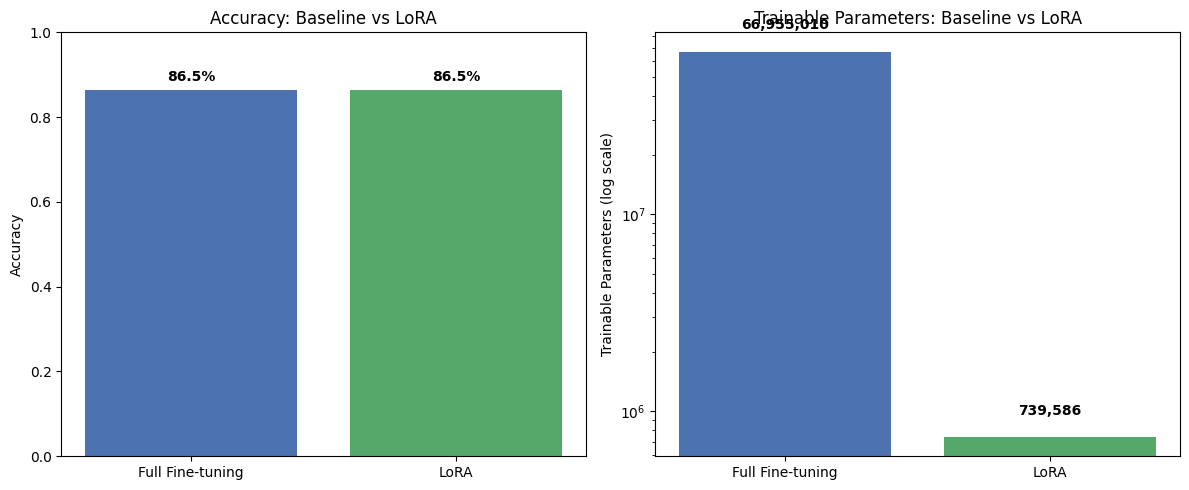

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Accuracy comparison
methods = ["Full Fine-tuning", "LoRA"]
accuracies = [0.865, 0.865]
axes[0].bar(methods, accuracies, color=["#4C72B0", "#55A868"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy: Baseline vs LoRA")
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")

# Graph 2: Trainable parameters comparison (log scale, since numbers are so different)
params = [66955010, 739586]
axes[1].bar(methods, params, color=["#4C72B0", "#55A868"])
axes[1].set_yscale("log")
axes[1].set_ylabel("Trainable Parameters (log scale)")
axes[1].set_title("Trainable Parameters: Baseline vs LoRA")
for i, v in enumerate(params):
    axes[1].text(i, v * 1.3, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150)
plt.show()

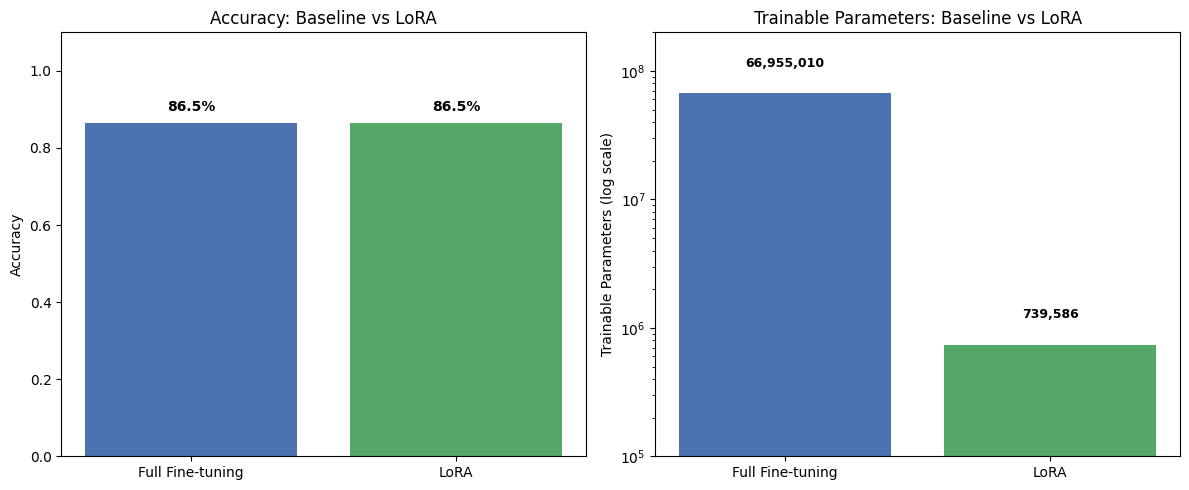

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

methods = ["Full Fine-tuning", "LoRA"]
accuracies = [0.865, 0.865]
axes[0].bar(methods, accuracies, color=["#4C72B0", "#55A868"])
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy: Baseline vs LoRA")
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.03, f"{v:.1%}", ha="center", fontweight="bold")

params = [66955010, 739586]
axes[1].bar(methods, params, color=["#4C72B0", "#55A868"])
axes[1].set_yscale("log")
axes[1].set_ylim(1e5, 2e8)   # more headroom so labels don't overlap
axes[1].set_ylabel("Trainable Parameters (log scale)")
axes[1].set_title("Trainable Parameters: Baseline vs LoRA")
for i, v in enumerate(params):
    axes[1].text(i, v * 1.6, f"{v:,}", ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("comparison_chart.png", dpi=150)
plt.show()

In [19]:
import os
for f in os.listdir():
    print(f)

.config
lora_results
comparison_results.csv
baseline_results.json
lora_results.json
baseline_results
comparison_chart.png
sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')